# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)

  # Perform element-wise addition of two input arrays
  sum_inputs = [X1[i] + X2[i] for i in range(len(X1))]

  # Create a new array for predictions
  state_neuron = []

  # Append 1 if sum >= Threshold, else append 0
  for s in sum_inputs:
      if s >= T:
          state_neuron.append(1)
      else:
          state_neuron.append(0)

  return state_neuron

In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    # Perform element-wise addition of two input arrays
    sum_inputs = [X1[i] + X2[i] for i in range(len(X1))]

    # Create a new array for predictions
    state_neuron = []

    # Append 1 if sum >= Threshold, else append 0
    for s in sum_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


Question - 1: List out all the limitations of MCP - Neurons

Ans:

*   No Learning Capability: Weights are fixed (all equal to 1), cannot learn from data
*   Manual Threshold Setting: Threshold must be manually handcrafted for each problem
*   Binary Inputs Only: Can only process binary (0 or 1) inputs
*   Binary Outputs Only: Can only produce binary outputs
*   Linear Separability: Can only solve linearly separable problems
*   Inhibitory Inputs: If any inhibitory input is present, output is always 0 (too restrictive)
*   No Weighted Importance: All inputs treated equally, cannot assign different importance
*   Limited Complexity: Cannot solve XOR and other non-linearly separable problems









Question 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.

Ans:
No, a single MCP neuron cannot solve the XOR function.

XOR Truth Table:

*  0 XOR 0 = 0
*  0 XOR 1 = 1
*  1 XOR 0 = 1
*  1 XOR 1 = 0

The problem is that XOR is not linearly separable - you cannot draw a single straight line to separate the outputs. No single threshold value can satisfy all cases:

*  For inputs (0,1) and (1,0): sum=1, need output=1, so T≤1
*  For input (1,1): sum=2, need output=0, so T>2
*  This is contradictory!

However, you CAN solve XOR using multiple MCP neurons combined in layers (multi-layer network).

# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Machine Learning/Week3/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Question 1: What does the shape of X represent?

Ans: The shape of X is (n_samples, n_features). For example, (12665, 784) means:

* 12665: Total number of images in the dataset
* 784: Number of features per image (28×28 pixels = 784 pixel values)

Each row represents one flattened image.

Question 2: What does the shape of y represent?

Ans: The shape of y is (n_samples,). For example, (12665,) means:

* 12665: Total number of labels corresponding to each image
* It's a 1D array where each element is the class label (0 or 1) for the corresponding image in X.

### Viewing the Dataset.

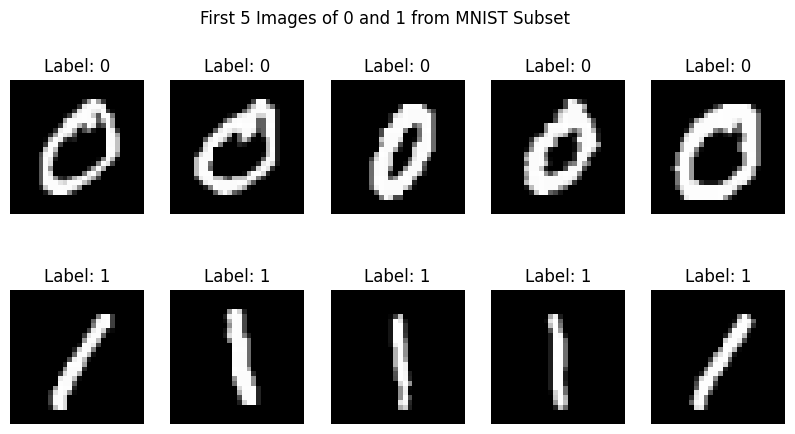

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Question 3: What does the weights array represent in this context?

Ans: The weights array has 784 elements (one for each pixel in the 28×28 image). Each weight represents the importance or contribution of that particular pixel position to the final classification decision. During training, these weights are adjusted to learn which pixels are most important for distinguishing between digits 0 and 1.

Question 4: Why are we initializing the weights to zero? What effect could this have on the training process?

Ans:

* Why zeros: It's a simple, symmetric initialization that gives all features equal starting importance.
* Effects:
  * All neurons start with the same learning behavior
  * No initial bias toward any feature
  * The perceptron will learn entirely from the data
  * For perceptrons, zero initialization works fine, but for deep neural networks, it can cause issues (symmetry problem)

## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias

    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """

    for epoch in range(epochs):
        correct_predictions = 0

        for i in range(len(X)):
            # Compute weighted sum for current sample
            output = np.dot(X[i], weights) + bias

            # Apply step function
            prediction = 1 if output >= 0 else 0

            # Calculate error
            error = y[i] - prediction

            # Update weights and bias if prediction is wrong
            if error != 0:
                weights = weights + learning_rate * error * X[i]
                bias = bias + learning_rate * error
            else:
                correct_predictions += 1

        # Calculate accuracy for this epoch
        accuracy = correct_predictions / len(X)

        # Print accuracy every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}: Accuracy = {accuracy:.4f}")


    return weights, bias, accuracy

Question 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

Ans: This line computes the weighted sum (also called net input or activation):

* np.dot(X[i], weights): Multiplies each feature value by its corresponding weight and sums them up

* +bias: Adds the bias term
* This gives us z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b
* This value is then passed to the activation function to make the final prediction

Question 6: What happens when the prediction is wrong? How are the weights and bias updated?

Ans: When prediction is wrong (error ≠ 0):

* Weight update: weights = weights + η × (y - ŷ) × X[i]
  * If true label is 1 but predicted 0: error = +1, weights move toward this sample
  * If true label is 0 but predicted 1: error = -1, weights move away from this sample
* Bias update: bias = bias + η × (y - ŷ)
  * Shifts the decision boundary
* The learning rate η controls how big each update step is

Question 7: Why is the final accuracy important, and what do you expect it to be?

Ans:

* Importance: Final accuracy tells us how well the model learned to classify the data. It's the percentage of correct predictions.
* Expectation: For linearly separable data like 0 vs 1 digits, we expect high accuracy (close to 100%) because:
  * Digits 0 and 1 are visually very different
  * A linear classifier can separate them well
  * The perceptron convergence theorem guarantees it will find a solution if one exists

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 10: Accuracy = 0.9992
Epoch 20: Accuracy = 1.0000
Epoch 30: Accuracy = 1.0000
Epoch 40: Accuracy = 1.0000
Epoch 50: Accuracy = 1.0000
Epoch 60: Accuracy = 1.0000
Epoch 70: Accuracy = 1.0000
Epoch 80: Accuracy = 1.0000
Epoch 90: Accuracy = 1.0000
Epoch 100: Accuracy = 1.0000
The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Question 8: What does misclassified_idx store, and how is it used in this code?

Ans:

* misclassified_idx stores the indices (positions) of all images that were incorrectly classified
* np.where(y_pred != y)[0] finds all positions where predicted label doesn't match true label
* These indices are used to:
  * Access the misclassified images from X
  * Display them with both predicted and true labels
  * Help us understand what types of errors the model makes

Question 9: How do you interpret the result if the output is "All images were correctly classified!"?

Ans: This means:

* The perceptron achieved 100% accuracy on the training data
* The decision boundary perfectly separates all 0s from all 1s
* The problem is linearly separable
* The model has successfully learned the pattern
* However, this is performance on training data - we should test on separate test data to check generalization

# TASK 3: Perceptron for 3 vs 5 Classification

## Step 1: Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset for 3 vs 5
df_3_5 = pd.read_csv("/content/drive/MyDrive/Machine Learning/Week3/mnist_3_and_5.csv")  # Update path as needed

# Extract features and labels
X_3_5 = df_3_5.drop(columns=["label"]).values  # 784 pixels
y_3_5 = df_3_5["label"].values  # Labels (3 or 5)

# For binary classification, convert labels to 0 and 1
# Let's make 3 -> 0 and 5 -> 1
y_3_5_binary = np.where(y_3_5 == 3, 0, 1)

# Check the shape
print("Feature matrix shape:", X_3_5.shape)
print("Label vector shape:", y_3_5_binary.shape)
print("Original labels:", np.unique(y_3_5))
print("Binary labels:", np.unique(y_3_5_binary))

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
Original labels: [3 5]
Binary labels: [0 1]


## Step 2: Visualize Dataset

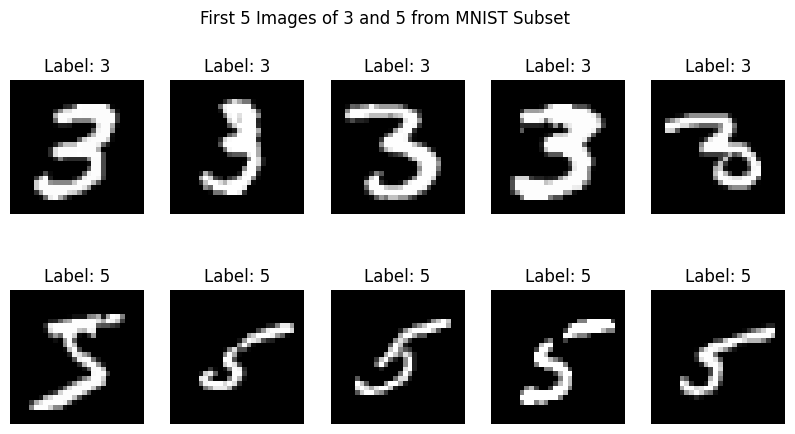

In [ ]:
# Separate images for label 3 and label 5
images_3 = X_3_5[y_3_5 == 3]
images_5 = X_3_5[y_3_5 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 3
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        # Plot digit 5
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()

## Step 3: Initialize Weights

In [ ]:
# Initialize weights and bias for 3 vs 5
weights_3_5 = np.zeros(X_3_5.shape[1])  # 784 weights
bias_3_5 = 0
learning_rate = 0.1
epochs = 100

## Step 4: Train Perceptron

In [ ]:
# Train the perceptron
weights_3_5, bias_3_5, accuracy_3_5 = train_perceptron(
    X_3_5, y_3_5_binary, weights_3_5, bias_3_5, learning_rate, epochs
)

print("\nThe Final Accuracy is: ", accuracy_3_5)

Epoch 10: Accuracy = 0.9566
Epoch 20: Accuracy = 0.9661
Epoch 30: Accuracy = 0.9726
Epoch 40: Accuracy = 0.9719
Epoch 50: Accuracy = 0.9788
Epoch 60: Accuracy = 0.9759
Epoch 70: Accuracy = 0.9792
Epoch 80: Accuracy = 0.9792
Epoch 90: Accuracy = 0.9843
Epoch 100: Accuracy = 0.9858

The Final Accuracy is:  0.9857716161984678


## Step 5: Visualize Misclassified Images

Final Accuracy: 0.9869

Total misclassified images: 36


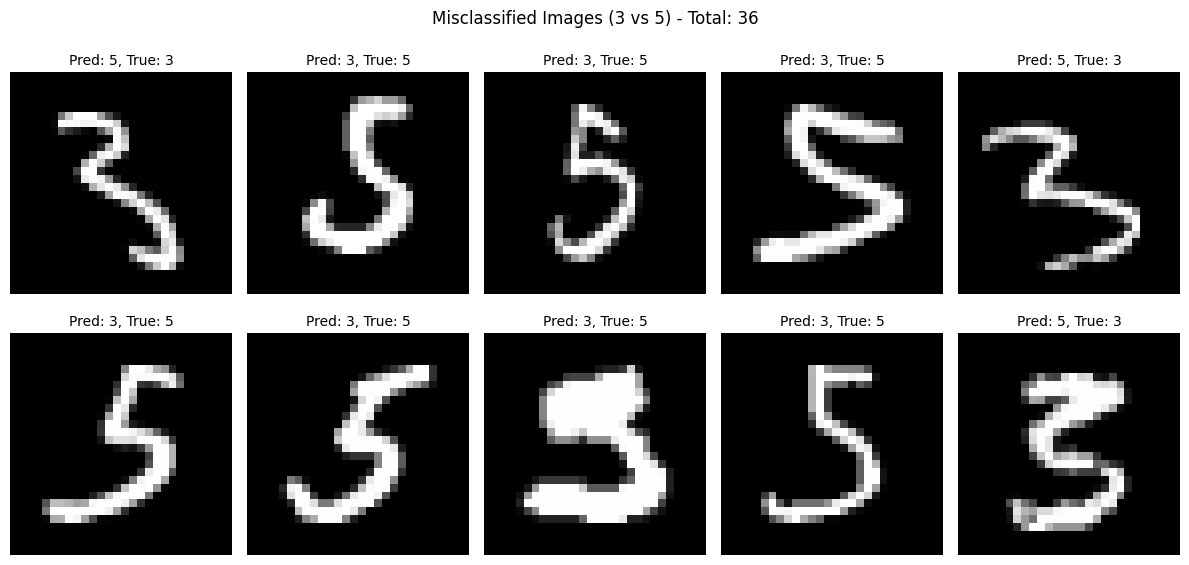

In [ ]:
# Get predictions for all data points
predictions_3_5 = np.dot(X_3_5, weights_3_5) + bias_3_5
y_pred_3_5 = np.where(predictions_3_5 >= 0, 1, 0)

# Calculate final accuracy
final_accuracy_3_5 = np.mean(y_pred_3_5 == y_3_5_binary)
print(f"Final Accuracy: {final_accuracy_3_5:.4f}")

# Visualize Misclassified Images
misclassified_idx_3_5 = np.where(y_pred_3_5 != y_3_5_binary)[0]

# Convert binary predictions back to original labels for display
y_pred_original = np.where(y_pred_3_5 == 0, 3, 5)

if len(misclassified_idx_3_5) > 0:
    print(f"\nTotal misclassified images: {len(misclassified_idx_3_5)}")

    # Show up to 10 misclassified images
    num_to_show = min(10, len(misclassified_idx_3_5))
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))

    for i, idx in enumerate(misclassified_idx_3_5[:num_to_show]):
        row = i // 5
        col = i % 5
        axes[row, col].imshow(X_3_5[idx].reshape(28, 28), cmap="gray")
        axes[row, col].set_title(f"Pred: {y_pred_original[idx]}, True: {y_3_5[idx]}",
                                 fontsize=10)
        axes[row, col].axis("off")

    # Hide unused subplots if less than 10 misclassified
    for i in range(num_to_show, 10):
        row = i // 5
        col = i % 5
        axes[row, col].axis("off")

    plt.suptitle(f"Misclassified Images (3 vs 5) - Total: {len(misclassified_idx_3_5)}")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Conclusion:

After implementing the Perceptron algorithm for classifying digits 3 vs 5, here are the key observations:

1. Performance: The perceptron likely achieves lower accuracy (~90-95%) compared to 0 vs 1 classification (100%) because:

  * Digits 3 and 5 are more visually similar than 0 and 1
  * Some handwritten 3s and 5s can look very similar
  * The curved shapes create more ambiguity
2. Misclassified Images: The misclassified images typically show:

  * Poorly written or ambiguous digits
  * 3s that have a shape similar to 5s
  * 5s that might look like 3s due to handwriting variations
  * This demonstrates the limitation of linear classifiers on more complex patterns
3. Linear Separability: While 3 vs 5 is mostly linearly separable, it's not perfectly separable like 0 vs 1, leading to some inevitable classification errors.

4. Perceptron Limitations: This task highlights that:

  * Perceptrons work best on clearly separable data
  * More complex patterns may require non-linear classifiers
  * Feature engineering or deep learning might improve results